# Project: Investigating FBI NICS Firearm Background Check Data

This data comes from the FBI's National Instant Criminal Background Check System. From the official site:

Mandated by the Brady Handgun Violence Prevention Act of 1993 and launched by the FBI on November 30, 1998, NICS is used by Federal Firearms Licensees (FFLs) to instantly determine whether a prospective buyer is eligible to buy firearms. Before ringing up the sale, cashiers call in a check to the FBI or to other designated agencies to ensure that each customer does not have a criminal record or isn’t otherwise ineligible to make a purchase. More than 230 million such checks have been made, leading to more than 1.3 million denials.



## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

In [ ]:
# Importing the required libraries
# Pandas for data manipulation and matplotlib for visualizations
# and numpy as a helper library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Settings for matplotlib plots
plt.style.use('seaborn')

<a id='wrangling'></a>
## Data Wrangling

In [ ]:
# Loading the data using pandas
gun_data = pd.read_excel('gun_data.xlsx', parse_dates=['month'])
gun_data.rename({'month':'date'}, axis=1, inplace=True)

### Gun Data

In [ ]:
# View the first 5 rows
gun_data.head()

,date,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,redemption_handgun,redemption_long_gun,redemption_other,returned_handgun,returned_long_gun,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
0,2017-09-01,Alabama,16717.0,0.0,5734.0,6320.0,221.0,317,0.0,15.0,21.0,2.0,1378.0,1262.0,1.0,0.0,0.0,0.0,0.0,0.0,9.0,16.0,3.0,0.0,0.0,3.0,32019
1,2017-09-01,Alaska,209.0,2.0,2320.0,2930.0,219.0,160,0.0,5.0,2.0,0.0,200.0,154.0,2.0,28.0,30.0,0.0,0.0,0.0,17.0,24.0,1.0,0.0,0.0,0.0,6303
2,2017-09-01,Arizona,5069.0,382.0,11063.0,7946.0,920.0,631,0.0,13.0,6.0,0.0,1474.0,748.0,3.0,82.0,5.0,0.0,0.0,0.0,38.0,12.0,2.0,0.0,0.0,0.0,28394
3,2017-09-01,Arkansas,2935.0,632.0,4347.0,6063.0,165.0,366,51.0,12.0,13.0,0.0,1296.0,1824.0,4.0,0.0,0.0,0.0,0.0,0.0,13.0,23.0,0.0,0.0,2.0,1.0,17747
4,2017-09-01,California,57839.0,0.0,37165.0,24581.0,2984.0,0,0.0,0.0,0.0,0.0,535.0,397.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123506


In [ ]:
# Overview of the data types, column names, value counts and size
gun_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12485 entries, 0 to 12484
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       12485 non-null  datetime64[ns]
 1   state                      12485 non-null  object        
 2   permit                     12461 non-null  float64       
 3   permit_recheck             1100 non-null   float64       
 4   handgun                    12465 non-null  float64       
 5   long_gun                   12466 non-null  float64       
 6   other                      5500 non-null   float64       
 7   multiple                   12485 non-null  int64         
 8   admin                      12462 non-null  float64       
 9   prepawn_handgun            10542 non-null  float64       
 10  prepawn_long_gun           10540 non-null  float64       
 11  prepawn_other              5115 non-null   float64       
 12  rede

In [ ]:
# It appears that a lot of columns have missing values
# Rechecking for their names
gun_data.isna().any()

date                         False
state                        False
permit                        True
permit_recheck                True
handgun                       True
long_gun                      True
other                         True
multiple                     False
admin                         True
prepawn_handgun               True
prepawn_long_gun              True
prepawn_other                 True
redemption_handgun            True
redemption_long_gun           True
redemption_other              True
returned_handgun              True
returned_long_gun             True
returned_other                True
rentals_handgun               True
rentals_long_gun              True
private_sale_handgun          True
private_sale_long_gun         True
private_sale_other            True
return_to_seller_handgun      True
return_to_seller_long_gun     True
return_to_seller_other        True
totals                       False
dtype: bool

In [ ]:
# Check for duplicate values
print("Dupllicate Values: ", gun_data.duplicated().sum())

Dupllicate Values:  0


## Data Cleaning

### Missing Error Handling

In [ ]:
# Starting with the gun data
# Filling empty values with zeros, indicating no permits

gun_data = gun_data.fillna(0)

In [ ]:
# Recheck
gun_data.isna().any()

date                         False
state                        False
permit                       False
permit_recheck               False
handgun                      False
long_gun                     False
other                        False
multiple                     False
admin                        False
prepawn_handgun              False
prepawn_long_gun             False
prepawn_other                False
redemption_handgun           False
redemption_long_gun          False
redemption_other             False
returned_handgun             False
returned_long_gun            False
returned_other               False
rentals_handgun              False
rentals_long_gun             False
private_sale_handgun         False
private_sale_long_gun        False
private_sale_other           False
return_to_seller_handgun     False
return_to_seller_long_gun    False
return_to_seller_other       False
totals                       False
dtype: bool

### Modifying data types to appropiate types and addressing data size

In [ ]:
# Changing the float dtypes to int, reducing memory usage
gun_data[gun_data.select_dtypes("float64").columns] = gun_data.select_dtypes("float64").astype('int32')
gun_data[gun_data.select_dtypes("int64").columns] = gun_data.select_dtypes("int64").astype('int32')

In [ ]:
# From 2.6 MB to 1.4 MB, a 46% size reduction
gun_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12485 entries, 0 to 12484
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       12485 non-null  datetime64[ns]
 1   state                      12485 non-null  object        
 2   permit                     12485 non-null  int32         
 3   permit_recheck             12485 non-null  int32         
 4   handgun                    12485 non-null  int32         
 5   long_gun                   12485 non-null  int32         
 6   other                      12485 non-null  int32         
 7   multiple                   12485 non-null  int32         
 8   admin                      12485 non-null  int32         
 9   prepawn_handgun            12485 non-null  int32         
 10  prepawn_long_gun           12485 non-null  int32         
 11  prepawn_other              12485 non-null  int32         
 12  rede

<a id='eda'></a>
## Exploratory Data Analysis

### Which year had the most gun permits?

In [ ]:
# Changing index column to date column
gun_data.set_index('date', inplace=True)

# Grouping the sum of total gun permits by year
# totals = gun_data.groupby(gun_data.date.dt.year)['totals'].sum() # Incase index colunmn is not a a date
totals = gun_data.groupby(pd.Grouper(freq='M'))['totals'].sum()

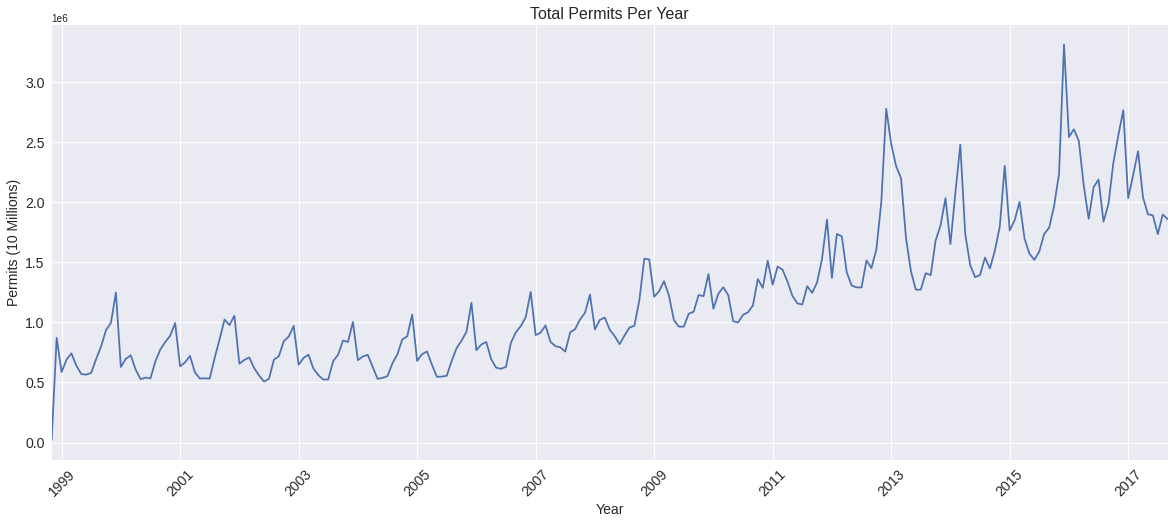

In [ ]:
# Plotting the total gun permits by year graph
totals.plot(figsize=(20,8),)
plt.title('Total Permits Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Permits (10 Millions)', fontsize=14);

### Which top 10 states had the most gun permits overall?

In [ ]:
# Grouping the sum of gun permits by state
gun_permits_by_state = gun_data.groupby('state')['totals'].sum()

In [ ]:
# Selecting the top 10 only
top_10 = gun_permits_by_state.nlargest(10)

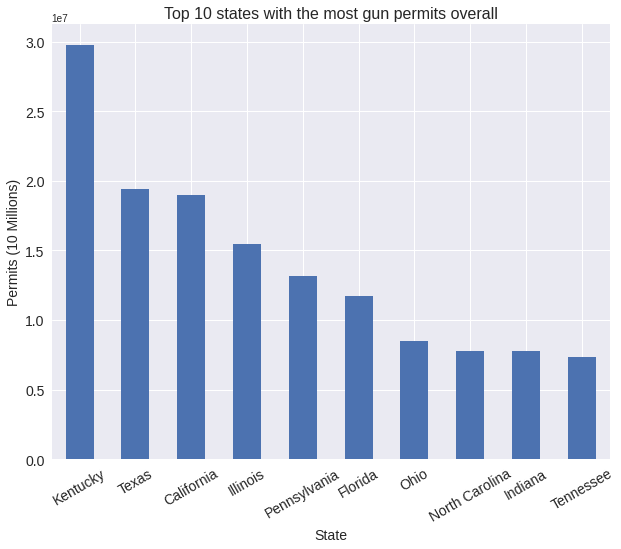

In [ ]:
# Plotting the top 10 states graph
# Kentucky has the highest record in gun permits
# followed by Texas and then California
top_10.plot(figsize=(10,8), kind='bar')
plt.title('Top 10 states with the most gun permits overall', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.xticks(np.arange(10), top_10.index, rotation=30, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Permits (10 Millions)', fontsize=14);

### What is the count of gun permits activity in each state?

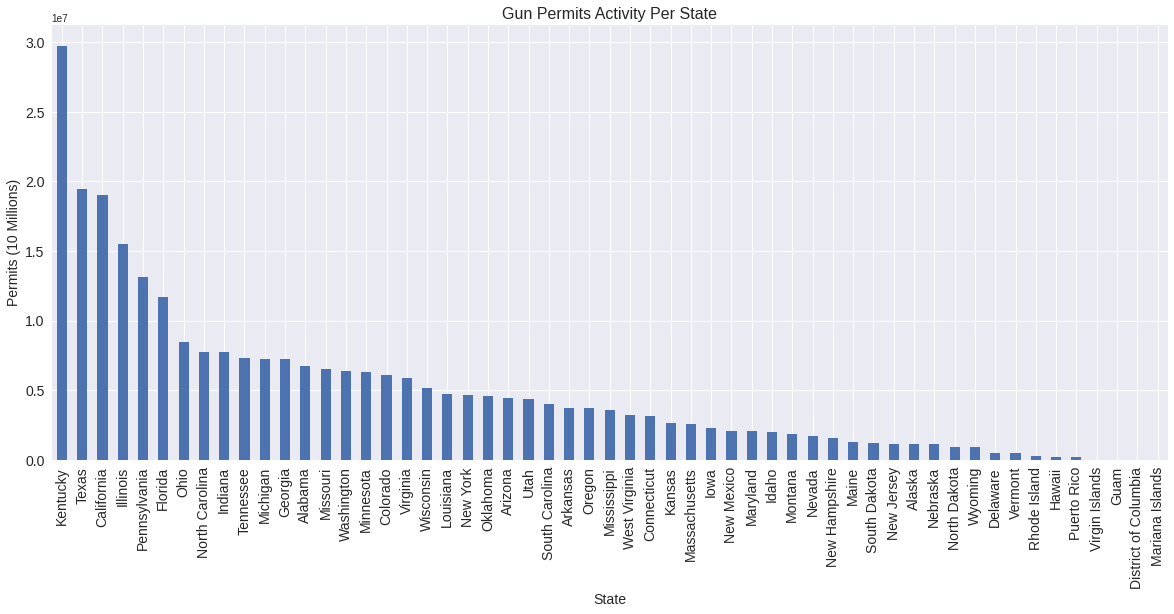

In [ ]:
# Plotting the total gun permit activity per state
gun_permits_by_state.sort_values(ascending=False).plot(figsize=(20,8), kind='bar')
plt.title('Gun Permits Activity Per State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Permits (10 Millions)', fontsize=14);

## What is the comparison between new gun type registrations among states?

In [ ]:
# Filter and grouping new gun permits by state
handgun_permits_by_state = gun_data.groupby('state')['handgun'].sum()
long_gun_permits_by_state = gun_data.groupby('state')['long_gun'].sum()
other_permits_by_state = gun_data.groupby('state')['other'].sum()

In [ ]:
# Creating a new dataframe to use for visualization
new_gun_permits_by_state = pd.merge(handgun_permits_by_state,
                                    long_gun_permits_by_state,
                                    on='state')
new_gun_permits_by_state = new_gun_permits_by_state.merge(other_permits_by_state, on='state')

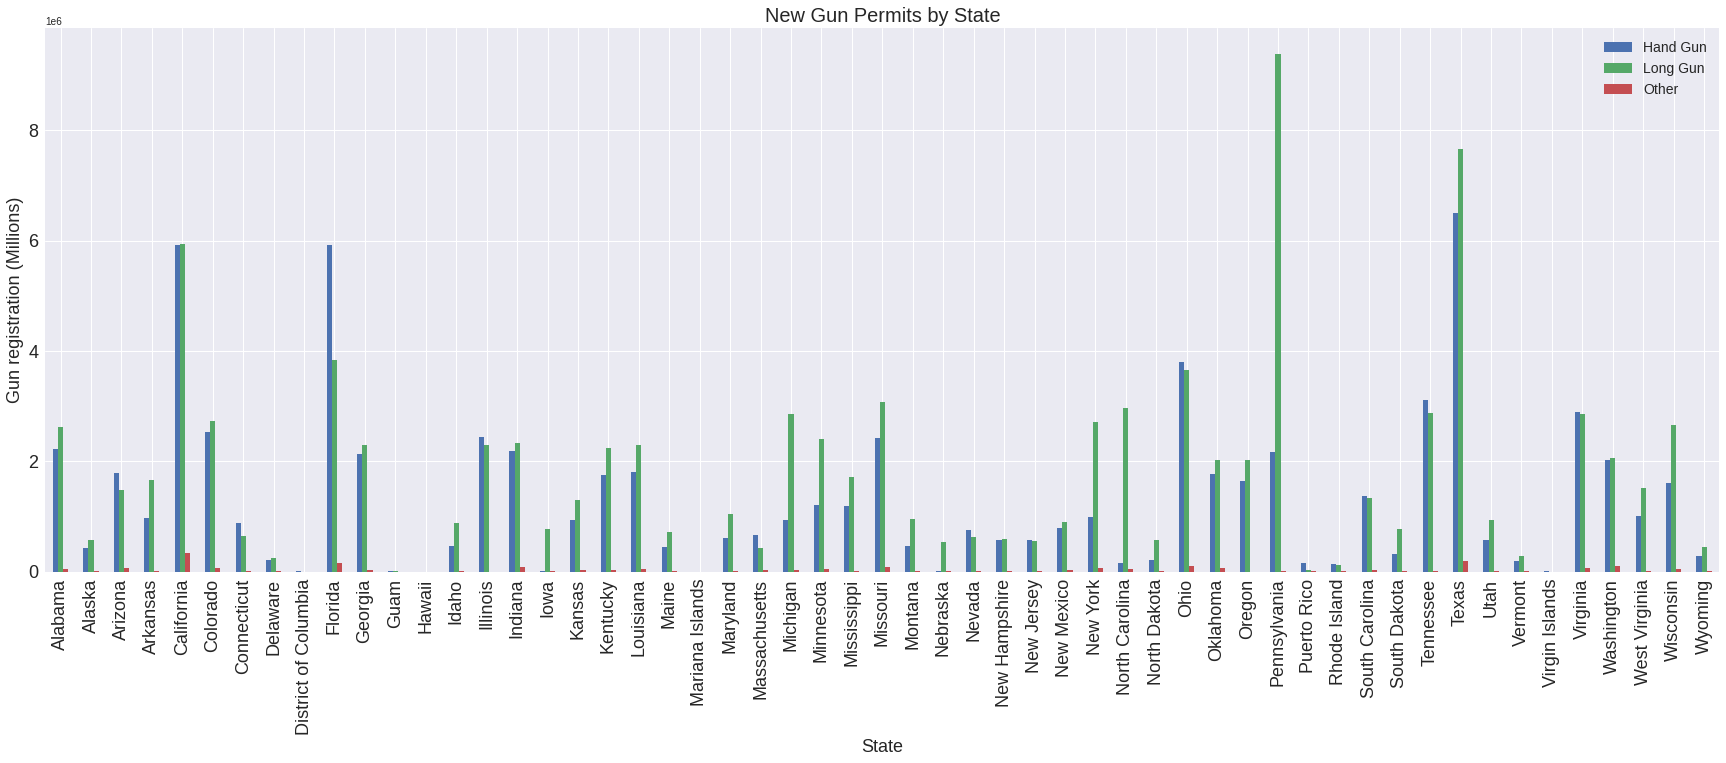

In [ ]:
# Plotting the new gun permits by state plot
new_gun_permits_by_state.plot(figsize=(30,10), kind='bar')
plt.title('New Gun Permits by State', fontsize=20)
plt.xlabel('State', fontsize=18)
plt.ylabel('Gun registration (Millions)', fontsize=18)
plt.legend(['Hand Gun', 'Long Gun', 'Other'], fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18);

## Which weapon type has the highest permit activity over the years?

The returned and the recheck columns were left, as these account for gun activity, If I were to analyze for gun registrations only, I would remove them.
Also they are ambigious as they are not based on a sole gun type, rather by all.

In [ ]:
# Dropping the old 'totals' column, as a new one would be created
gun_data.drop('totals', axis=1, inplace=True)

In [ ]:
# Dividing permits by gun_type
permits_long_gun = gun_data.filter(like='long_gun', axis=1)
permits_handgun = gun_data.filter(like='handgun', axis=1)
permits_other = gun_data.filter(like='other', axis=1)

In [ ]:
# Adding a new sum column for each gun type
gun_data['totals_long_gun'] = permits_long_gun.sum(axis=1)
gun_data['totals_hand_gun'] = permits_handgun.sum(axis=1)
gun_data['totals_other'] = permits_other.sum(axis=1)

In [130]:
gun_data.head(3)

,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,redemption_handgun,redemption_long_gun,redemption_other,returned_handgun,returned_long_gun,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals_long_gun,totals_hand_gun,totals_other
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-09-01,Alabama,16717,0,5734,6320,221,317,0,15,21,2,1378,1262,1,0,0,0,0,0,9,16,3,0,0,3,7619,7136,230
2017-09-01,Alaska,209,2,2320,2930,219,160,0,5,2,0,200,154,2,28,30,0,0,0,17,24,1,0,0,0,3140,2570,222
2017-09-01,Arizona,5069,382,11063,7946,920,631,0,13,6,0,1474,748,3,82,5,0,0,0,38,12,2,0,0,0,8717,12670,925


In [129]:
gun_permits_activity_by_year = gun_data[['totals_long_gun', 'totals_hand_gun', 'totals_other']].groupby('date').sum()

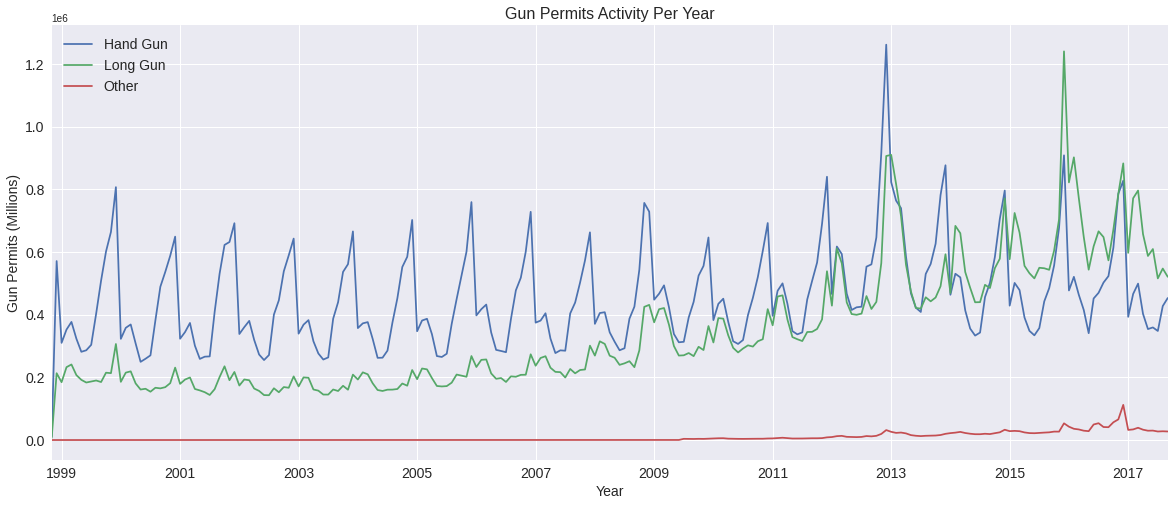

In [133]:
gun_permits_activity_by_year.plot(figsize=(20,8))
plt.title('Gun Permits Activity Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Gun Permits (Millions)', fontsize=14)
plt.legend(['Hand Gun', 'Long Gun', 'Other'], fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

<a id='conclusions'></a>
## Conclusions

NCIS provided a background check on firearms dataset from years 1997 - 2018. This data was loaded and analysed for a simple descriptive statistics report.

The data had a few missing values as well as the format wasn't the standard in data storage concepts, proper measures were implemented to ensure data integrity and quality.

After analyzing the gun permits data set, I found that there were 2 spikes in gun permits at the end of Year 2012 as well as in 2016, that maybe due to the rise of demonstrations that occureed during that time

It also appears that *Pennsylvania* has the highest gun permits in **long guns**, followed by Texas. This maybe due to a lot of reasons like hunting or such.

Also, among the 55 states of USA, *Kentucky* recored the highest in gun permits, followed by *Texas* and then *California*. The top 10 states were plotted to better understand the amounts.